Some good metrics to consider include localization accuracy, grounding accuracy, and semantic similarity. Localization accuracy measures how accurately the system can localize an object in the image, while grounding accuracy measures how accurately it can ground the localized object to a language description. Semantic similarity measures the similarity between the predicted bounding boxes and the ground-truth descriptions. Intersection over Union (IoU) is a common measure of localization accuracy, while recall is used to measure grounding accuracy. Cosine similarity and Euclidean distance are commonly used to measure semantic similarity. Evaluating the model using these metrics can provide valuable insights into the model’s performance and areas for improvement.

In [1]:
import numpy as np
import torch
import clip

In [2]:
if torch.backends.mps.is_available():
    print("MPS backend is available.")
    device = torch.device('mps')
elif torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

CUDA backend is available.


In [3]:
device

device(type='cuda')

In [4]:
import pickle
import json

In [5]:
with open("../refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("../refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [6]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [7]:
import os
import pandas as pdß
import numpy as np
import pprint
import json
import cv2
import random

import pickle # Load refs and annotations
from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchmetrics


import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw

from ipywidgets import FloatProgress

In [8]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, annotations, split="train"):

        dataset = list()

        for elem in [d for d in refs if d["split"]==split]:
            file_name = os.path.join("../refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            sentences = elem['sentences']
            raws = []
            for i in sentences:
                raws.append(i['raw'])
            bbox = annotations[elem['ann_id']]
            for i in raws:
                dataset.append({"file_name":file_name,"raw":i,"bbox":bbox})

        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [9]:
def pad_image(image):
    """
    Performs bottom-right padding of the original image to 640x640 (max size of images in the dataset).
    Bottom-right padding prevents corruption of bounding boxes.

    ### Arguments
    image: a PIL.Image to transform
    """
    padded_width, padded_height = 640, 640
    original_height, original_width = image.shape[:2]
    bottom_padding = padded_height - original_height
    right_padding = padded_width - original_width
    top_padding = 0
    left_padding = 0
    
    padded_image = cv2.copyMakeBorder(image, top_padding, bottom_padding, left_padding, right_padding, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded_image 

def collate_fn(batch):
    #print("Actual batch is made of : " + batch)
    images = []
    data = {}

    #Stores all images in a list
    for sample in batch:
        image = cv2.imread(sample["file_name"], 3)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = pad_image(image=image)

        y_ = image.shape[0]
        x_ = image.shape[1]


        images.append(transform(image))

        data['raw'] = sample['raw']
        x,y,z,c = sample['bbox'][0:4]
        y1=y 
        x1=x 
        y2=(y + c)
        x2=(x + z)

        data['bbox'] = [x,y,x2,y2]
        data['filename'] = sample["file_name"]
            
    images = torch.stack(images, dim=0)
    """
    for key in batch[0].keys():
        #if key != "file_name":
        #    data[key] = [sample[key] for sample in batch]
        data[key] = [sample[key] for sample in batch]
        if( key == 'bbox'):
            x,y,z,c = sample[key][0:4]
            y1=y 
            x1=x 
            y2=(y + z)
            x2=(x + c)
    """
    return images, data

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [10]:
# create dataset and dataloader
dataset_test = RefCOCOG(refs, annotations, split="test")
dataset_valid = RefCOCOG(refs, annotations, split="train")
#print(dataset_valid[1]['file_name'])
print("---------------------------------------------------")
#plt.imshow(Image.open(dataset[2]["file_name"]))
dataloader_test = DataLoader(dataset_test, batch_size=4, collate_fn=collate_fn, num_workers=0)
dataloader_valid = DataLoader(dataset_test, batch_size=4, collate_fn=collate_fn, num_workers=0)


---------------------------------------------------


In [11]:
dataset_test[0]

{'file_name': '../refcocog/images/COCO_train2014_000000380440.jpg',
 'raw': 'the man in yellow coat',
 'bbox': [374.31, 65.06, 136.04, 201.94]}

In [12]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [13]:
clip_model.eval()

CLIP(
  (visual): ModifiedResNet(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu3): ReLU(inplace=True)
    (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
     

In [14]:
"""
Forward pass of CLIP. Its almost the same from the laboratory
"""
def forward(self, image, text):
    image_features = self.encode_image(image)
    text_features = self.encode_text(text)

    # normalized features
    image_features = image_features / image_features.norm(dim=1, keepdim=True)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)

    # cosine similarity as logits
    logit_scale = self.logit_scale.exp()
    logits_per_image = logit_scale * image_features @ text_features.t()
    logits_per_text = logits_per_image.t()

    # shape = [global_batch_size, global_batch_size]
    return logits_per_image, logits_per_text

In [15]:
help(clip_model)

Help on CLIP in module clip.model object:

class CLIP(torch.nn.modules.module.Module)
 |  CLIP(embed_dim: int, image_resolution: int, vision_layers: Union[Tuple[int, int, int, int], int], vision_width: int, vision_patch_size: int, context_length: int, vocab_size: int, transformer_width: int, transformer_heads: int, transformer_layers: int)
 |  
 |  Method resolution order:
 |      CLIP
 |      torch.nn.modules.module.Module
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, embed_dim: int, image_resolution: int, vision_layers: Union[Tuple[int, int, int, int], int], vision_width: int, vision_patch_size: int, context_length: int, vocab_size: int, transformer_width: int, transformer_heads: int, transformer_layers: int)
 |      Initialize internal Module state, shared by both nn.Module and ScriptModule.
 |  
 |  build_attention_mask(self)
 |  
 |  encode_image(self, image)
 |  
 |  encode_text(self, text)
 |  
 |  forward(self, image, text)
 |      Define the co

In [16]:
import torch
import clip
from PIL import Image, ImageDraw
import cv2
import numpy as np
from ultralytics import YOLO

In [17]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################

class YolottoClip():
    def __init__(self, clip_model, clip_preprocess):

        self.yolo = YOLO("yolov8n.pt")
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess

    def infer_bboxes(self, image_path):
        results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        return bboxes

    def encode_image(self, image):
        # Load and preprocess the image using CLIP preprocess function
        image = self.clip_preprocess(image).unsqueeze(0).to(self.device)

        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features

    def encode_text(self, text):
        # Encode the text using the CLIP model
        text = clip.tokenize(text).to(self.device)
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)

        return text_features

    def calculate_best_bbox(self, image_path, caption, device):
        text = clip.tokenize(caption).to(device)
        best_score = 0
        best_bbox = None
        candidates = []

        for bbox in self.infer_bboxes(image_path):
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).unsqueeze(0).to(device)

            with torch.no_grad():
                logits_per_image, logits_per_text = self.clip_model(image, text)
                matching_score = logits_per_text.cpu().numpy()[0]

            candidates.append((matching_score,bbox))

            if matching_score > best_score:
                best_score = matching_score
                best_bbox = bbox

        return best_score, best_bbox, candidates
    
    def calculate_best_bbox(self, image_path, caption, device):
        text = clip.tokenize(caption).to(device)
        best_score = 0
        best_bbox = None
        candidates = []

        for bbox in self.infer_bboxes(image_path):
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).unsqueeze(0).to(device)

            with torch.no_grad():
                logits_per_image, logits_per_text = self.clip_model(image, text)
                matching_score = logits_per_text.cpu().numpy()[0]

            candidates.append((matching_score,bbox))

            if matching_score > best_score:
                best_score = matching_score
                best_bbox = bbox

        return best_score, best_bbox, candidates
    

In [18]:
ZeroShotter = YolottoClip(clip_model,clip_preprocess)

In [19]:
img = 'zidane.jpg'
caption = 'bald man with a tie'

In [20]:
yolo = YOLO("yolov8n.pt")

In [21]:
class LossMeter:
    def __init__(self, name="Metric"):
        self.name = name
        self.losses = []
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = 0,0,0

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count
        self.losses.append([self.count, self.sum, self.avg])

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

In [22]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding 

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area


In [23]:
def compare_candidate_bbox(imagepath, bbox1, bbox2):
    image = cv2.imread(imagepath)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    color = other_bbox_color
    cv2.rectangle(image, (int(bbox1[0]), int(bbox1[1])) ,(int(bbox1[2]), int(bbox1[3])), color, 2)

    color = max_bbox_color
    cv2.rectangle(image, (int(bbox2[0]), int(bbox2[1])) ,(int(bbox2[2]), int(bbox2[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

In [24]:
def forward(self, image, text):

    text = clip.tokenize(caption).to(device)

    image_features = self.encode_image(image)
    text_features = self.encode_text(text)

    # normalized features
    image_features = image_features / image_features.norm(dim=1, keepdim=True)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)

    # cosine similarity as logits
    logit_scale = self.logit_scale.exp()
    logits_per_image = logit_scale * image_features @ text_features.t()
    logits_per_text = logits_per_image.t()

    # shape = [global_batch_size, global_batch_size]
    return logits_per_image, logits_per_text

In [25]:
NUM_EPOCHS = 1
count = 0
loss_meter = LossMeter()
iou_threshold = 0.5

running_loc_acc = 0.0
correct_bboxes = 0
overall = 0
running_ss = 0
semantic_similarity = 0

for epoch in range(NUM_EPOCHS):
    loop = tqdm(dataloader_test, position=0, leave=True)
    for iter in enumerate(loop):
        try:
            data = iter[1][1]
            #print(data)
            #print('-'*70)

            raw_text = data['raw']
            bbox_gt = data['bbox']
            filename = data['filename']
            # since confidence is directly how much bbox and text "resembles" each other 
            confidence, bbox_e, candidates = ZeroShotter.calculate_best_bbox(filename,caption,device)

            #print(bbox_gt)
            bbox_e = [int(bbox_e[0]), int(bbox_e[1]), int(bbox_e[2]), int(bbox_e[3])]
            #print(bbox_e)
            #print('-'*70)
            #print(bbox_e)
            #print(bbox_gt)
            max_iou = 0.0
            for bbox_e in candidates:
                pred = compute_iou(bbox_gt,bbox_e[1])
                if pred > max_iou:
                    max_iou = pred
                #print(pred)

            running_loc_acc += max_iou
                

            if(pred > iou_threshold):
                #compare_candidate_bbox(filename,bbox_e, bbox_gt)
                correct_bboxes += 1
                overall += 1
                running_ga = correct_bboxes / overall
            else:
                overall += 1
                running_ga = correct_bboxes / overall

            running_ss += confidence[0] / 100
            semantic_similarity = running_ss / overall
            loc_acc = running_loc_acc / overall
        except:
            print(filename)

        loop.set_description(f"Localization accuracy = {loc_acc}, Grounding Accuracy = {running_ga}, Semantic Similarity = {semantic_similarity}")

  0%|          | 0/2401 [00:00<?, ?it/s]

/home/matea/Documents/GitHub/DL2023-Carolo-Maines/Bagigi/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


../refcocog/images/COCO_train2014_000000047116.jpg
../refcocog/images/COCO_train2014_000000159038.jpg
../refcocog/images/COCO_train2014_000000079887.jpg


In [ ]:
iou_threshold = 0.5

In [ ]:
for epoch in range(NUM_EPOCHS):
    loop = tqdm(dataloader_test, position=0, leave=True)
    for iter in enumerate(loop):
        try:
            data = iter[1][1]
            #print(data)
            #print('-'*70)

            raw_text = data['raw']
            bbox_gt = data['bbox']
            filename = data['filename']
            # since confidence is directly how much bbox and text "resembles" each other 
            confidence, bbox_e, candidates = ZeroShotter.calculate_best_bbox(filename,caption,device)


In [ ]:
confidence, bboxe, rest = ZeroShotter.calculate_best_bbox(img,caption,device)


image 1/1 /Users/mattiacarolo/Documents/GitHub/DL2023-Carolo-Maines/Experiments/zidane.jpg: 384x640 2 persons, 1 tie, 84.6ms
Speed: 2.5ms preprocess, 84.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


tensor(123.4520)
tensor(746.5687)
tensor(436.7941)


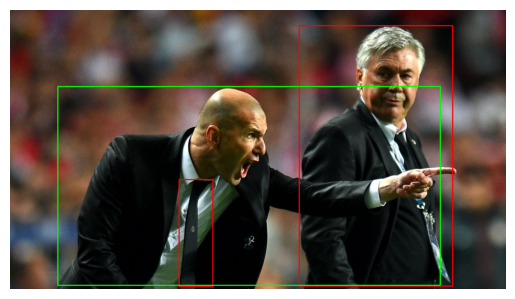

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread(img)

# Find the bbox with the highest score
max_score = -1
max_bbox = None


# Define colors
max_bbox_color = (0, 255, 0)  # Green for the highest score bbox
other_bbox_color = (0, 0, 255)  # Red for other bboxes

# Plot all bboxes
for score, bbox in rest:
    print(bbox[0])
    color = other_bbox_color
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), color, 2)

color = max_bbox_color
cv2.rectangle(image, (int(bboxe[0]), int(bboxe[1])) ,(int(bboxe[2]), int(bboxe[3])), color, 2)

# Convert the image from BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()